<a href="https://colab.research.google.com/github/naz-picones/MO-IT128-DMP-A3107-Lucero-Picones-Ramos/blob/main/Revised_MO_IT128_Homework_Project_Clustering_and_Segmentation_BSIT_A3107_Lucero%2CC_J%2C_Ramos%2C_M_G%2C_Picones%2CM_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Loading and Overview

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [97]:
df = pd.read_csv("FinMark_Final.csv")

display(df.head())
print(df.shape)
print(df.columns.tolist())

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Transaction_Amount_log,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,month,Total_Spend,Avg_Transaction_Value,Transaction_Count,months_since_last_transaction,Transaction_Type_Encoded,total_spend_log
0,49,234,2023-01-03 00:00:00,1926.0,Investment,7.563720,5.0,Needs improvement,10,2023-01,13926.0,2321.000000,6,0,1,9.541585
1,50,141,2023-01-03 01:00:00,3422.0,Purchase,8.138273,8.0,Unsatisfactory,10,2023-01,11646.0,2911.500000,4,0,3,9.362804
2,51,708,2023-01-03 02:00:00,2509.0,Loan Payment,7.828038,8.0,Very satisfied,7,2023-01,6181.0,2060.333333,3,0,2,8.729397
3,52,498,2023-01-03 03:00:00,3450.0,Investment,8.146419,9.0,Good service,3,2023-01,18333.0,3055.500000,6,0,1,9.816513
4,53,555,2023-01-03 04:00:00,3555.0,Loan Payment,8.176392,10.0,Very satisfied,5,2023-01,15942.0,2657.000000,6,0,2,9.676775


(5000, 16)
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Transaction_Type', 'Transaction_Amount_log', 'Satisfaction_Score', 'Feedback_Comments', 'Likelihood_to_Recommend', 'month', 'Total_Spend', 'Avg_Transaction_Value', 'Transaction_Count', 'months_since_last_transaction', 'Transaction_Type_Encoded', 'total_spend_log']


##Customer Data Aggregation (RFM Preparation)

In [98]:
customer_profile = df.groupby("Customer_ID").agg({
    "Transaction_Amount": "sum",
    "Transaction_ID": "count",
    "months_since_last_transaction": "mean",
    "Satisfaction_Score": "mean"
}).reset_index()

customer_profile.columns = [
    "Customer_ID",
    "Total_Amount",
    "Transaction_Count",
    "Recency",
    "Avg_Satisfaction_Score"
]

display(customer_profile.head())
print(customer_profile.shape)

,Customer_ID,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score
0,1,16836.0,6,1.0,10.0
1,2,4907.0,2,1.5,7.0
2,3,1538.0,1,0.0,10.0
3,4,8295.0,2,2.5,7.0
4,5,14798.0,5,1.0,8.0


(993, 5)


##Feature Selection and Data Cleaning

In [99]:
selected_features = [
    "Total_Amount",
    "Transaction_Count",
    "Recency",
    "Avg_Satisfaction_Score"
]

X = customer_profile[selected_features].copy()

# Fill missing values if any
X = X.fillna(X.median(numeric_only=True))

print("Selected features:", selected_features)
display(X.head())

Selected features: ['Total_Amount', 'Transaction_Count', 'Recency', 'Avg_Satisfaction_Score']


,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score
0,16836.0,6,1.0,10.0
1,4907.0,2,1.5,7.0
2,1538.0,1,0.0,10.0
3,8295.0,2,2.5,7.0
4,14798.0,5,1.0,8.0


##Feature Scaling

In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (993, 4)


##Optimal Cluster Selection (Elbow Method)

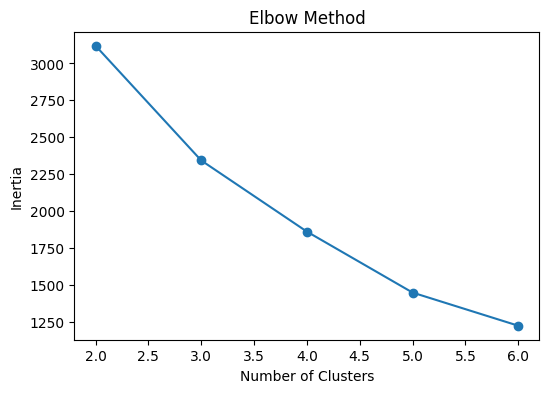

In [101]:
inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

##Cluster Validation (Silhouette Analysis)

,K,Silhouette Score
0,2,0.780426
1,3,0.268064
2,4,0.294162
3,5,0.307809
4,6,0.314306


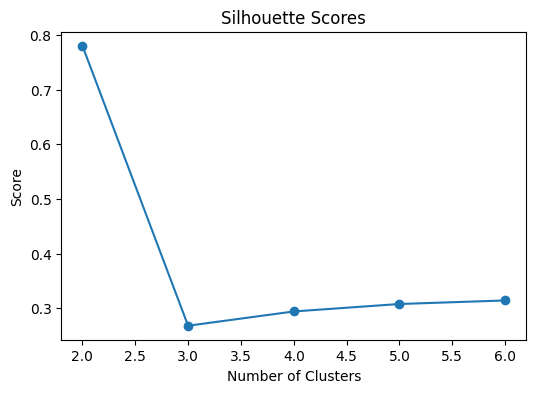

Best k based on silhouette: 2
Best silhouette score: 0.78


In [102]:
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)

# 📊 CREATE TABLE
silhouette_table = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouettes
})

display(silhouette_table)

# 📈 PLOT
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouettes, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

# BEST K
best_k = silhouette_table.loc[silhouette_table["Silhouette Score"].idxmax(), "K"]
best_score = silhouette_table["Silhouette Score"].max()

print("Best k based on silhouette:", best_k)
print("Best silhouette score:", round(best_score, 3))

##K-Means Clustering Implementation

In [103]:
K = 2  # following best k based on silhouette score
kmeans = KMeans(n_clusters=K, n_init=10)

customer_profile["Cluster"] = kmeans.fit_predict(X_scaled)

display(customer_profile.head())

,Customer_ID,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score,Cluster
0,1,16836.0,6,1.0,10.0,0
1,2,4907.0,2,1.5,7.0,1
2,3,1538.0,1,0.0,10.0,1
3,4,8295.0,2,2.5,7.0,1
4,5,14798.0,5,1.0,8.0,1


##Cluster Profiling and Summary

In [104]:
cluster_summary = customer_profile.groupby("Cluster")[selected_features].mean().round(2)
cluster_counts = customer_profile["Cluster"].value_counts().sort_index()

display(cluster_summary)
display(cluster_counts)

,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score
Cluster,,,,
0,24260.57,7.05,0.70,8.61
1,8552.63,3.51,1.02,8.70


,count
Cluster,
0,427
1,566


##Customer Segment Naming and Interpretation

In [105]:
cluster_summary["Score"] = (
    cluster_summary["Total_Amount"].rank(ascending=False) +
    cluster_summary["Transaction_Count"].rank(ascending=False)
)

best_cluster = cluster_summary["Score"].idxmin()

cluster_names = {}

for cl in cluster_summary.index:
    if cl == best_cluster:
        cluster_names[cl] = "High-Value Frequent Customers"
    elif cluster_summary.loc[cl, "Total_Amount"] >= cluster_summary["Total_Amount"].median():
        cluster_names[cl] = "Moderate-Value Customers"
    else:
        cluster_names[cl] = "Low-Value Occasional Customers"

customer_profile["Cluster_Name"] = customer_profile["Cluster"].map(cluster_names)

print("Cluster names:")
print(cluster_names)

display(customer_profile.head())

Cluster names:
{0: 'High-Value Frequent Customers', 1: 'Low-Value Occasional Customers'}


,Customer_ID,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score,Cluster,Cluster_Name
0,1,16836.0,6,1.0,10.0,0,High-Value Frequent Customers
1,2,4907.0,2,1.5,7.0,1,Low-Value Occasional Customers
2,3,1538.0,1,0.0,10.0,1,Low-Value Occasional Customers
3,4,8295.0,2,2.5,7.0,1,Low-Value Occasional Customers
4,5,14798.0,5,1.0,8.0,1,Low-Value Occasional Customers


##Segment-Level Summary

In [106]:
cluster_summary_named = customer_profile.groupby("Cluster_Name")[selected_features].mean().round(2)
cluster_counts_named = customer_profile["Cluster_Name"].value_counts()

display(cluster_summary_named)
display(cluster_counts_named)

,Total_Amount,Transaction_Count,Recency,Avg_Satisfaction_Score
Cluster_Name,,,,
High-Value Frequent Customers,24260.57,7.05,0.70,8.61
Low-Value Occasional Customers,8552.63,3.51,1.02,8.70


,count
Cluster_Name,
Low-Value Occasional Customers,566
High-Value Frequent Customers,427


##Dimensionality Reduction using PCA

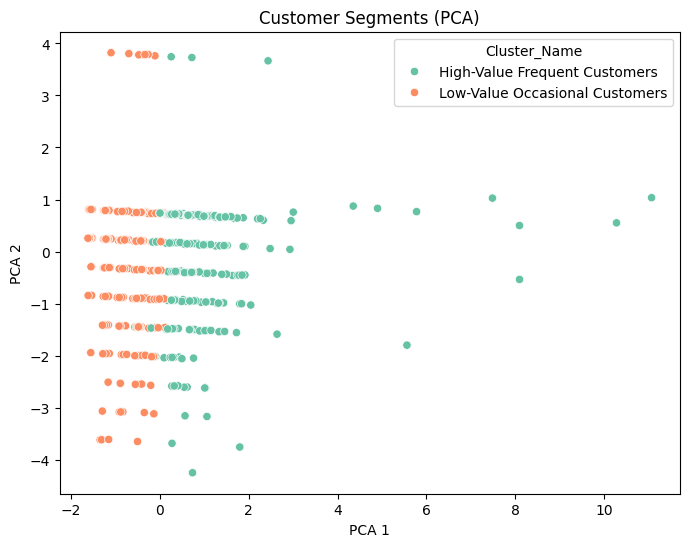

In [107]:
customer_profile["PCA1"] = coords[:, 0]
customer_profile["PCA2"] = coords[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customer_profile,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Name",
    palette="Set2"
)
plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

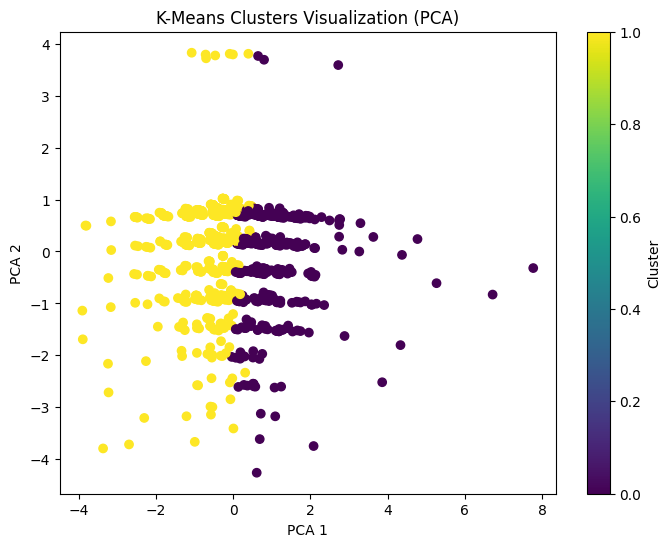

Explained variance by PCA components: [0.343 0.25 ]
PCA Loadings:


,PCA 1,PCA 2
Total_Amount,0.451,-0.071
Transaction_Count,0.682,-0.060
Recency,-0.575,-0.071
Avg_Satisfaction_Score,0.032,0.993


In [108]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

"""## PCA Visualization by Cluster Number"""

plt.figure(figsize=(8,6))
plt.scatter(coords[:, 0], coords[:, 1], c=customer_profile["Cluster"], cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Visualization (PCA)")
plt.colorbar(label="Cluster")
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_.round(3))

loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=["PCA 1", "PCA 2"]
)

print("PCA Loadings:")
display(loadings.round(3))

##PCA Feature Contribution Analysis

In [109]:
print("Explained variance by PCA components:", pca.explained_variance_ratio_.round(3))

loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=["PCA 1", "PCA 2"]
)

print("PCA Loadings:")
display(loadings.round(3))

Explained variance by PCA components: [0.343 0.25 ]
PCA Loadings:


,PCA 1,PCA 2
Total_Amount,0.451,-0.071
Transaction_Count,0.682,-0.060
Recency,-0.575,-0.071
Avg_Satisfaction_Score,0.032,0.993


##Feature Correlation Analysis

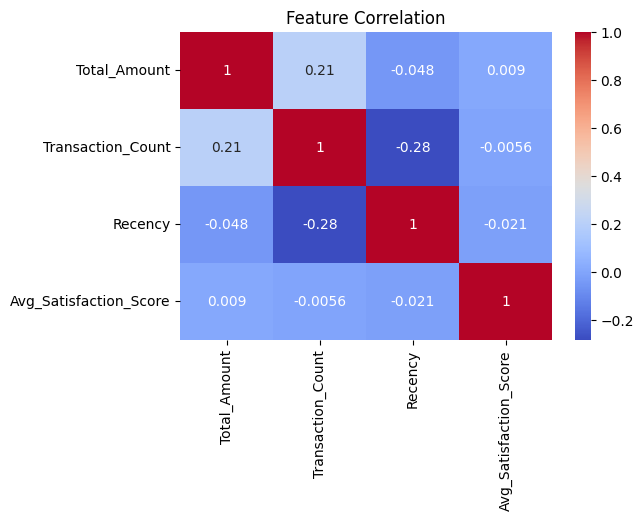

In [110]:
plt.figure(figsize=(6, 4))
sns.heatmap(customer_profile[selected_features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

##Customer Segment Insights

In [111]:
print("Customer Segment Descriptions:")

for cl, name in cluster_names.items():
    spend = cluster_summary.loc[cl, "Total_Amount"]
    freq = cluster_summary.loc[cl, "Transaction_Count"]
    size = cluster_counts[cl]

    description = f"{name}: "

    if name == "High-Value Frequent Customers":
        description += (
            "These customers spend the most and purchase the most often. "
            "They are the most valuable segment and are likely loyal customers."
        )
    elif name == "Moderate-Value Customers":
        description += (
            "These customers show average spending and moderate purchase frequency. "
            "They have potential for upselling and retention strategies."
        )
    else:
        description += (
            "These customers spend less and buy less often. "
            "They may need promotions or engagement strategies to increase activity."
        )

    description += f" Cluster size = {size}."
    print("-", description)

Customer Segment Descriptions:
- High-Value Frequent Customers: These customers spend the most and purchase the most often. They are the most valuable segment and are likely loyal customers. Cluster size = 427.
- Low-Value Occasional Customers: These customers spend less and buy less often. They may need promotions or engagement strategies to increase activity. Cluster size = 566.


In [112]:
summary = cluster_summary.copy()

spend_col = "Total_Amount"
lines = []

for cl in summary.index:
    line = (
        f"Cluster {cl}: "
        f"{spend_col}={summary.loc[cl, spend_col]:.2f}, "
        f"Transaction_Count={summary.loc[cl, 'Transaction_Count']:.2f}, "
        f"Recency={summary.loc[cl, 'Recency']:.2f}, "
        f"Avg_Satisfaction_Score={summary.loc[cl, 'Avg_Satisfaction_Score']:.2f}, "
        f"size={cluster_counts[cl]}"
    )
    lines.append(line)

print("DRAFT NOTES (edit these into your write-up):")
for l in lines:
    print("-", l)

DRAFT NOTES (edit these into your write-up):
- Cluster 0: Total_Amount=24260.57, Transaction_Count=7.05, Recency=0.70, Avg_Satisfaction_Score=8.61, size=427
- Cluster 1: Total_Amount=8552.63, Transaction_Count=3.51, Recency=1.02, Avg_Satisfaction_Score=8.70, size=566


In [113]:
"""##Export Final Results"""

customer_profile.to_csv("FinMark_Final_Clustered_Output.csv", index=False)
print("Saved as FinMark_Final_Clustered_Output.csv")

Saved as FinMark_Final_Clustered_Output.csv
